# Semiconductor Data Preparation & EDA

This notebook covers:
1. Data loading and exploration
2. Missingness analysis
3. Data cleaning strategy
4. Feature engineering
5. Full EDA and assumption validation
6. Feature correlation and encoding

## Step 1: Install and Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
#load the dataset
df = pd.read_csv('chip_dataset.csv')

In [6]:
df.head()

,Unnamed: 0,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN


## Exploratory Data Analysis

In [7]:
#gather information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             4854 non-null   int64  
 1   Product                4854 non-null   str    
 2   Type                   4854 non-null   str    
 3   Release Date           4854 non-null   str    
 4   Process Size (nm)      4845 non-null   float64
 5   TDP (W)                4228 non-null   float64
 6   Die Size (mm^2)        4139 non-null   float64
 7   Transistors (million)  4143 non-null   float64
 8   Freq (MHz)             4854 non-null   float64
 9   Foundry                4854 non-null   str    
 10  Vendor                 4854 non-null   str    
 11  FP16 GFLOPS            536 non-null    float64
 12  FP32 GFLOPS            1948 non-null   float64
 13  FP64 GFLOPS            1306 non-null   float64
dtypes: float64(8), int64(1), str(5)
memory usage: 531.0 KB


In [8]:
#check mean, median, mode, standard deviation, minimum and maximum values of the dataset
df.describe()

,Unnamed: 0,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
count,4854.000000,4845.000000,4228.000000,4139.000000,4143.000000,4854.000000,536.000000,1948.000000,1306.000000
mean,2426.500000,55.109598,81.359981,188.440445,1929.922279,1484.406057,8397.459851,2134.756653,363.670511
std,1401.373433,44.998676,76.807808,126.189383,4044.891098,1066.701523,13799.551131,3898.431487,1145.931856
min,0.000000,0.000000,1.000000,1.000000,8.000000,100.000000,10.020000,12.800000,3.600000
25%,1213.250000,22.000000,33.000000,104.000000,154.000000,590.000000,768.800000,257.300000,38.295000
50%,2426.500000,40.000000,65.000000,148.000000,624.000000,1073.500000,2965.500000,696.000000,89.280000
75%,3639.750000,90.000000,100.000000,239.000000,1550.000000,2400.000000,10600.000000,2116.750000,220.000000
max,4853.000000,250.000000,900.000000,826.000000,54200.000000,4700.000000,184600.000000,40000.000000,11540.000000


## Check for Distribution of numeric Values

In [10]:
#Drop the 'id' column as it is not useful for analysis
df1 = df.drop(columns =['Unnamed: 0'])

In [13]:
#Select numeric columns
numeric_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']


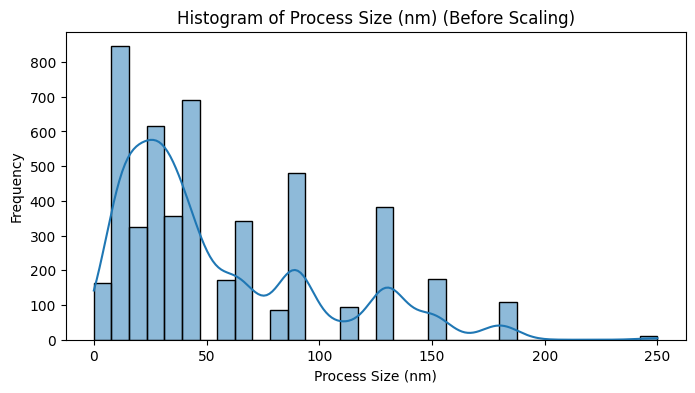

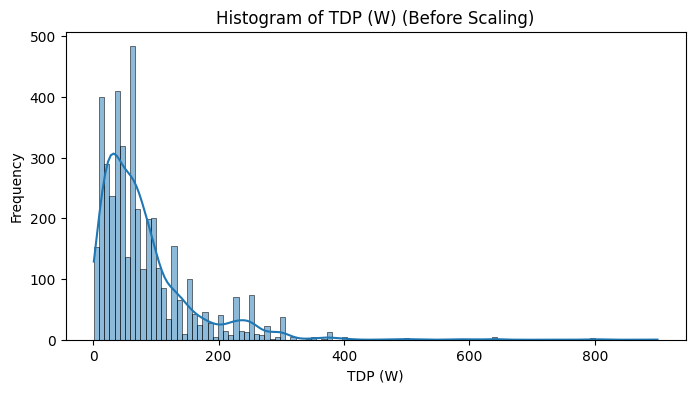

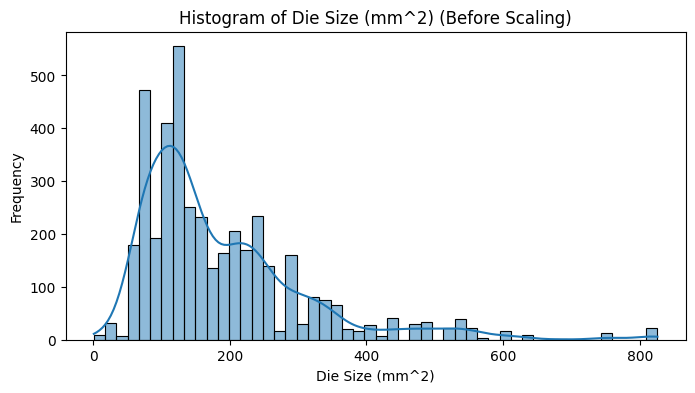

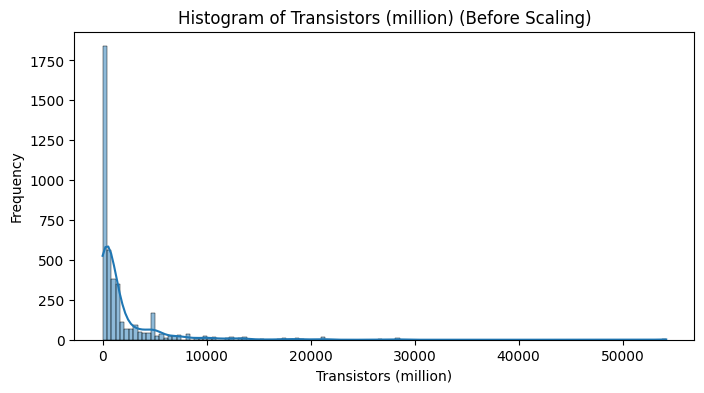

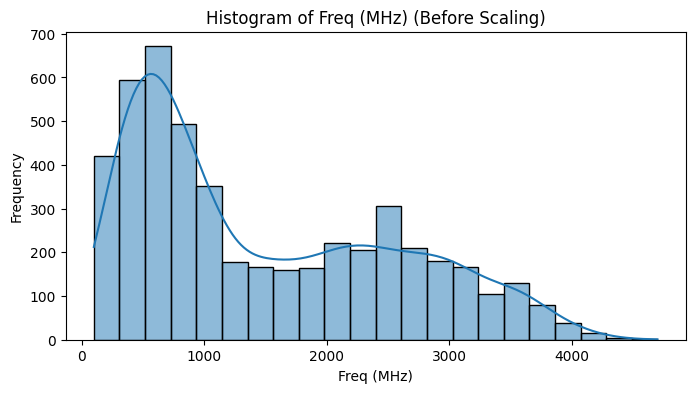

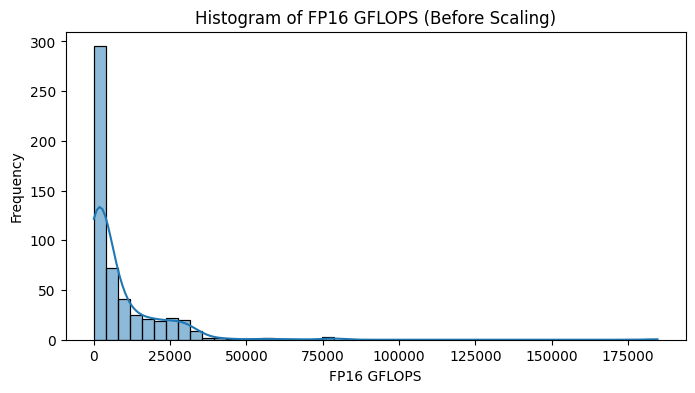

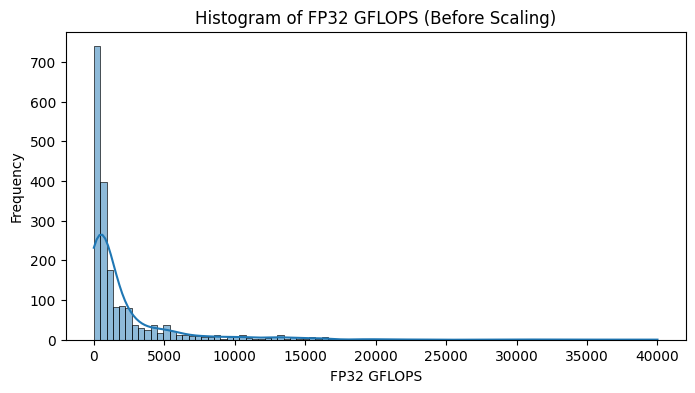

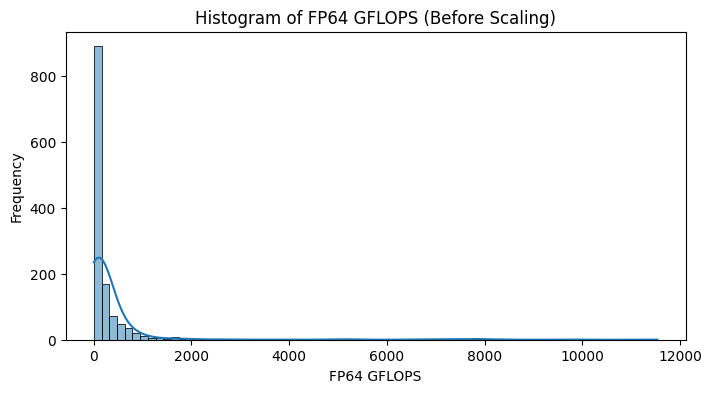

In [14]:
#plot histograms for numeric columns (before scaling)
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df1[col], kde=True)
    plt.title(f'Histogram of {col} (Before Scaling)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


## Target Variable Analysis 

In [ ]:
#target variable analysis
df1['']

## Missing Value Analysis

In [17]:
df1.isnull().sum()

Product                     0
Type                        0
Release Date                0
Process Size (nm)           9
TDP (W)                   626
Die Size (mm^2)           715
Transistors (million)     711
Freq (MHz)                  0
Foundry                     0
Vendor                      0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
dtype: int64

In [18]:
# convert to percentage
missing_percentage = (df1.isnull().sum() / len(df1)) * 100
print(missing_percentage)

Product                   0.000000
Type                      0.000000
Release Date              0.000000
Process Size (nm)         0.185414
TDP (W)                  12.896580
Die Size (mm^2)          14.730119
Transistors (million)    14.647713
Freq (MHz)                0.000000
Foundry                   0.000000
Vendor                    0.000000
FP16 GFLOPS              88.957561
FP32 GFLOPS              59.868150
FP64 GFLOPS              73.094355
dtype: float64


## Visualize missing data

In [19]:
import missingno as msno

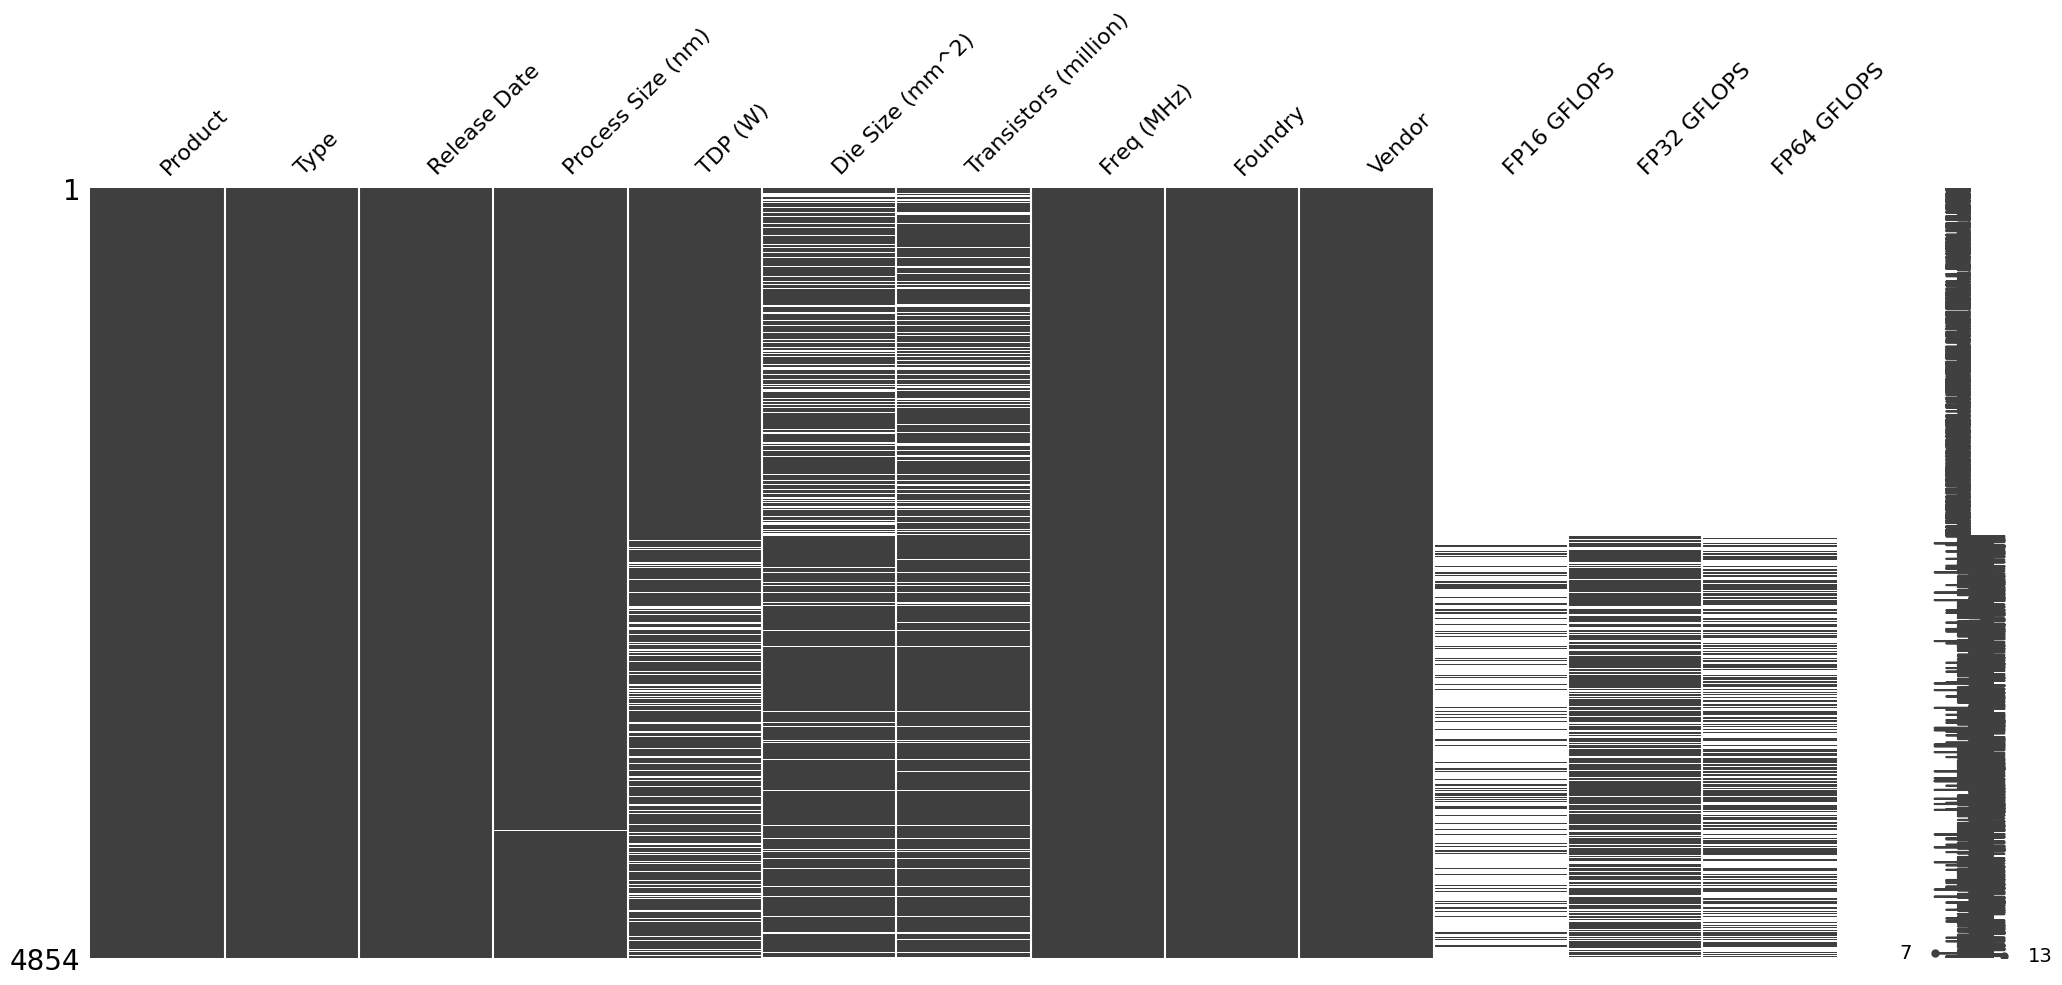

In [20]:
msno.matrix(df1)
plt.show()

In [23]:
# Categorize columns as numerical or categorical
categorical_cols = df1.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: ['Product', 'Type', 'Release Date', 'Foundry', 'Vendor']
Numerical columns: ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']


C:\Users\HP\AppData\Local\Temp\ipykernel_9296\3693536365.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df1.select_dtypes(include=['object']).columns.tolist()


## Detect outliers with box plots

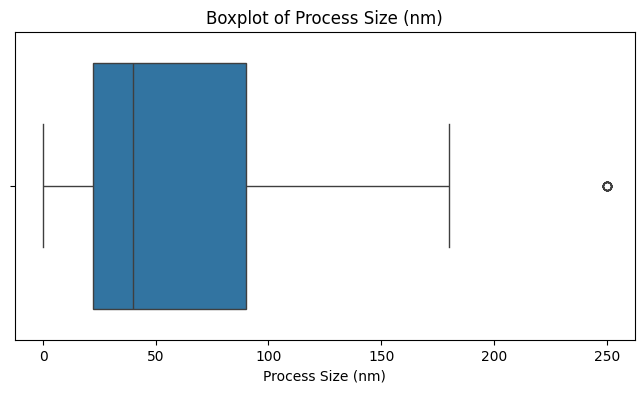

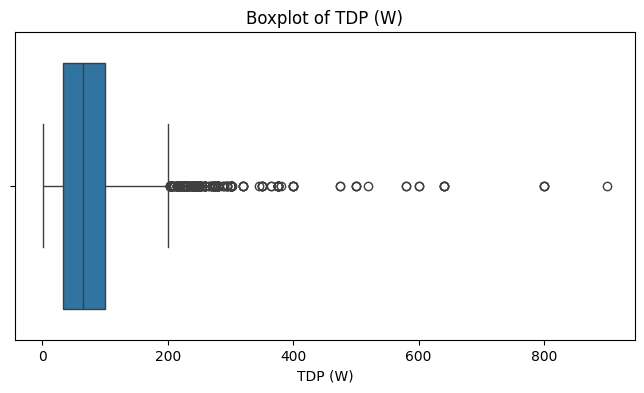

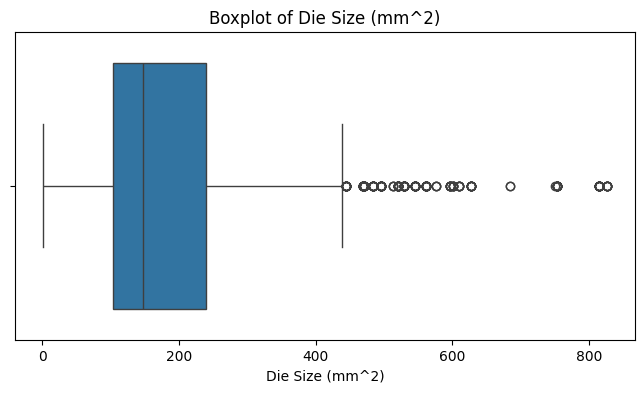

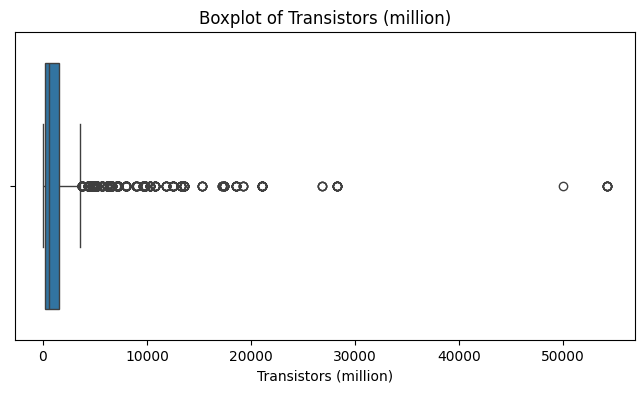

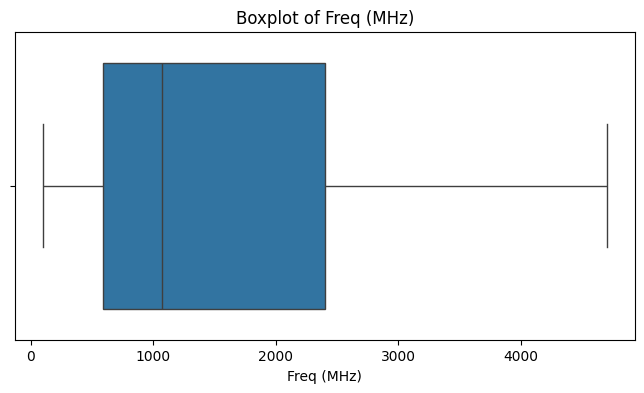

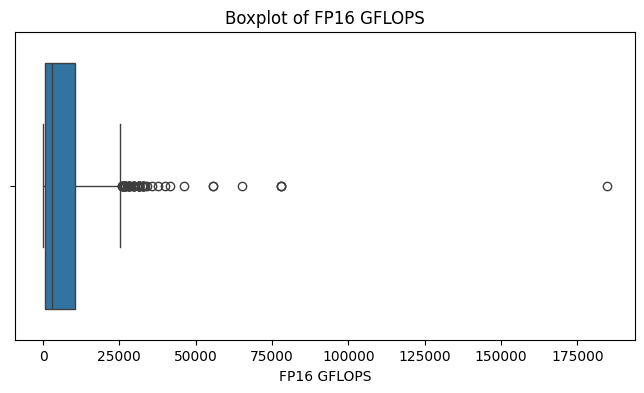

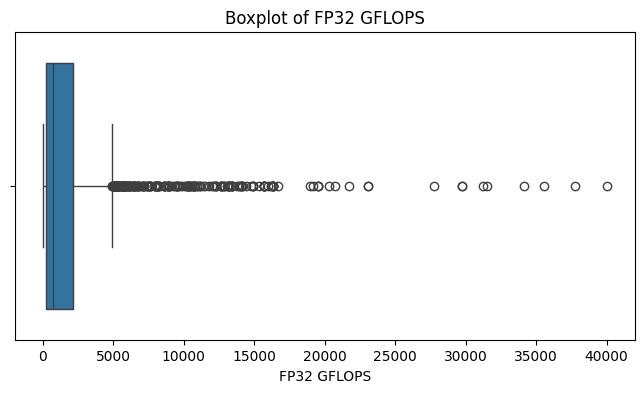

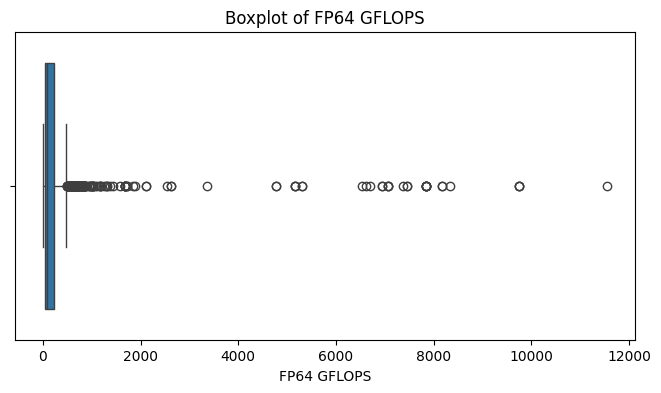

In [60]:
# check for outliers in numerical columns using boxplots
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

## Step 4: Develop Data Cleaning Strategy & Clean Data

In [24]:
strategy = """
STRATEGY FOR HANDLING MISSING VALUES:

1. FP16/FP32/FP64 GFLOPS (59-89% missing):
    These are GPU-specific metrics. Most CPUs don't have these.
   - ACTION: DROP these columns - they're not essential for general analysis
   
2. Die Size (mm^2), Transistors (14.6-14.7% missing):
    Moderate missingness, but essential for Moore's Law analysis
   - ACTION: Impute using median grouped by Type (CPU/GPU) and Vendor
   - REASON: Die size and transistor count vary by chip category
   
3. TDP (W) (12.9% missing):
   Important performance metric
   - ACTION: Impute using mean grouped by Type and Vendor
   - REASON: Power consumption patterns differ by chip type
   
4. Process Size (nm) (0.19% missing):
   Very minimal missing, critical for Moore's Law
   - ACTION: Impute using forward fill by Release Date (chronological)
   - REASON: Process technology progresses over time
   
5. Foundry = "Unknown":
    'Unknown' is not truly missing, it's a category
   - ACTION: Keep as is (represents actual unknown foundries)
   
6. Product Column:
   - ACTION: Drop - not needed for analysis (just a name identifier)
   
7. Release Date:
   - ACTION: Convert to datetime format for temporal analysis
"""

print(strategy)




STRATEGY FOR HANDLING MISSING VALUES:

1. FP16/FP32/FP64 GFLOPS (59-89% missing):
    These are GPU-specific metrics. Most CPUs don't have these.
   - ACTION: DROP these columns - they're not essential for general analysis

2. Die Size (mm^2), Transistors (14.6-14.7% missing):
    Moderate missingness, but essential for Moore's Law analysis
   - ACTION: Impute using median grouped by Type (CPU/GPU) and Vendor
   - REASON: Die size and transistor count vary by chip category

3. TDP (W) (12.9% missing):
   Important performance metric
   - ACTION: Impute using mean grouped by Type and Vendor
   - REASON: Power consumption patterns differ by chip type

4. Process Size (nm) (0.19% missing):
   Very minimal missing, critical for Moore's Law
   - ACTION: Impute using forward fill by Release Date (chronological)
   - REASON: Process technology progresses over time

5. Foundry = "Unknown":
    'Unknown' is not truly missing, it's a category
   - ACTION: Keep as is (represents actual unknown f

In [25]:
# Create a copy for cleaning
df_clean = df1.copy()

In [26]:
#  1. Drop non-consequential columns
print(" Drop Non-Consequential Columns")


cols_to_drop = ['Product', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {list(df_clean.columns)}")

 Drop Non-Consequential Columns
Dropped columns: ['Product', 'FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS']
Remaining columns: ['Type', 'Release Date', 'Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'Foundry', 'Vendor']


In [29]:
#2. Convert Release Date to datetime
df_clean['Release Date'] = pd.to_datetime(df_clean['Release Date'], errors='coerce')

In [35]:
#3. Handle missing values in Process Size(0.19% missing)
#foward fill by Release Date (chronological)
df_clean = df_clean.sort_values('Release Date')
df_clean['Process Size (nm)'] = df_clean['Process Size (nm)'].ffill()

# Fill any remaining with median
df_clean['Process Size (nm)'].fillna(df_clean['Process Size (nm)'].median(), inplace=True)



C:\Users\HP\AppData\Local\Temp\ipykernel_9296\3886581837.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Process Size (nm)'].fillna(df_clean['Process Size (nm)'].median(), inplace=True)


4421    150.0
4357    250.0
3074    250.0
3721    180.0
3500    180.0
        ...  
4737     10.0
4798     12.0
4810     14.0
4820     28.0
4833     28.0
Name: Process Size (nm), Length: 4854, dtype: float64

In [48]:
print(df_clean.columns)

Index(['Type', 'Release Date', 'Process Size (nm)', 'TDP (W)',
       'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'Foundry',
       'Vendor'],
      dtype='str')


In [ ]:
# 4. Handle missing values in Die Size and Transistors (14.6-14.7% missing)
# Impute using median grouped by Type and Vendor

for col in ['Die Size (mm^2)', 'Transistors (million)']:
     missing_before = df_clean[col].isnull().sum()

     df_clean[col] = df_clean.groupby(['Type', 'Vendor'])[col].transform(lambda x: x.fillna(x.median()))
     missing_after = df_clean[col].isnull().sum()
print(f"{col}: Missing before = {missing_before}, Missing after = {missing_after}")


#fill any remaining with median
for col in ['Die Size (mm^2)', 'Transistors (million)']:
    missing_before = df_clean[col].isnull().sum()
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
    missing_after = df_clean[col].isnull().sum()
    
    print(f"{col}: Missing before = {missing_before}, Missing after = {missing_after}")

In [51]:
print("\nFinal dataset missing values:")
print(df_clean.isnull().sum().sum())


Final dataset missing values:
701


In [52]:
# 5.handle missing values in TDP (12.9% missing)
# Impute using mean grouped by Type and Vendor
for col in ['TDP (W)']:
     missing_before = df_clean[col].isnull().sum()

     df_clean[col] = df_clean.groupby(['Type', 'Vendor'])[col].transform(lambda x: x.fillna(x.mean()))
     missing_after = df_clean[col].isnull().sum()
     print(f"{col}: Missing before = {missing_before}, Missing after = {missing_after}")

TDP (W): Missing before = 626, Missing after = 0


In [58]:
# 6. handle missing values in release date with overall median date
for col in ['Release Date']:
    if df_clean[col].isnull().sum() > 0:
        missing_before = df_clean[col].isnull().sum()
    
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        missing_after = df_clean[col].isnull().sum()

        print(f"{col}: Missing before = {missing_before}, Missing after = {missing_after}")

Release Date: Missing before = 75, Missing after = 0


In [59]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4854 entries, 4421 to 4833
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Type                   4854 non-null   str           
 1   Release Date           4854 non-null   datetime64[us]
 2   Process Size (nm)      4854 non-null   float64       
 3   TDP (W)                4854 non-null   float64       
 4   Die Size (mm^2)        4854 non-null   float64       
 5   Transistors (million)  4854 non-null   float64       
 6   Freq (MHz)             4854 non-null   float64       
 7   Foundry                4854 non-null   str           
 8   Vendor                 4854 non-null   str           
dtypes: datetime64[us](1), float64(5), str(3)
memory usage: 379.2 KB


In [64]:
#5.transform temporal data to their correct format (date time)
df_clean['Release Date'] = pd.to_datetime(df_clean['Release Date'], errors='coerce')

df_clean.head()

,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,Year,Year_Month,Year_Range
4421,GPU,2000-01-01,150.0,38.674419,133.0,1160.0,133.0,Intel,Intel,2000,2000-01,2000-2005
4357,GPU,2000-03-01,250.0,98.844650,90.0,15.0,105.0,TSMC,NVIDIA,2000,2000-03,2000-2005
3074,GPU,2000-03-04,250.0,79.000000,279.0,54.0,147.0,Sony,Other,2000,2000-03,2000-2005
3721,GPU,2000-04-01,180.0,23.000000,115.0,30.0,166.0,TSMC,ATI,2000,2000-04,2000-2005
3500,GPU,2000-04-01,180.0,23.000000,111.0,30.0,166.0,TSMC,ATI,2000,2000-04,2000-2005


In [68]:
# Assumption 1. MOORE'S LAW ANALYSIS especially in GPUs 
# Create Release Year from date
df_clean['Release Year'] = df_clean['Release Date'].dt.year

# Calculate process size halving rate(process size trend 2015+)
recent_process = df_clean[df_clean['Year'] >= 2015].groupby('Year')['Process Size (nm)'].median()


# Transistor trends (Moore's Law)
print(" Transistor Growth Over Time")

yearly_transistors = df_clean.groupby('Year')['Transistors (million)'].agg(['mean', 'max', 'median'])
print("\nTransistor count trends (millions):")
print(yearly_transistors.tail(10))

 Transistor Growth Over Time

Transistor count trends (millions):
             mean      max  median
Year                              
2012  1428.141994   7080.0  1178.0
2013  1813.189112   7080.0  1303.0
2014  1936.682692   7100.0  1400.0
2015  2087.314554   8900.0  1400.0
2016  3892.969466  15300.0  2940.0
2017  4048.853211  21100.0  3000.0
2018  4994.926108  21100.0  3300.0
2019  4717.069652  21100.0  3800.0
2020  6769.275862  54200.0  3300.0
2021  4128.587413  54200.0   504.0


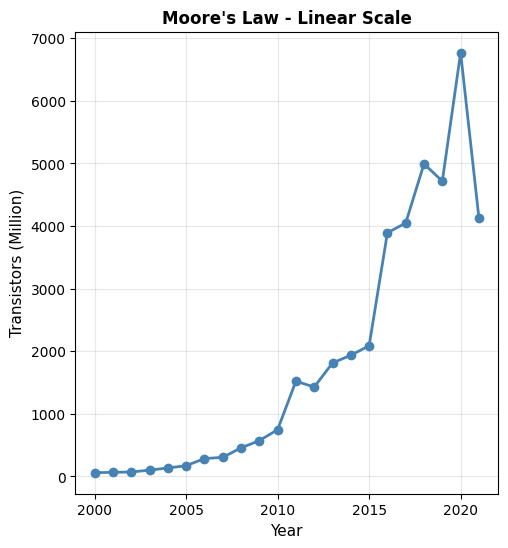

In [70]:
# Moore's Law Visualization - Simple Graph
plt.figure(figsize=(12, 6))

# Get yearly transistor averages
yearly_transistors_avg = df_clean.groupby('Year')['Transistors (million)'].mean().sort_index()

# Plot 1: Linear Scale
plt.subplot(1, 2, 1)
plt.plot(yearly_transistors_avg.index, yearly_transistors_avg.values, 'o-', linewidth=2, markersize=6, color='steelblue')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Transistors (Million)', fontsize=11)
plt.title("Moore's Law - Linear Scale", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.show()



In [72]:
# Assumption 2: Dennard Scaling Analysis
# Dennard scaling hypothesis: as transistors shrink, power consumption per transistor decreases


# Remove rows with invalid TDP or Transistor values
df_dennard = df_clean[(df_clean['TDP (W)'] > 0) & (df_clean['Transistors (million)'] > 0)].copy()

# Calculate key metrics
df_dennard['Performance_per_Watt'] = df_dennard['Transistors (million)'] / df_dennard['TDP (W)']
df_dennard['Power_per_Transistor_mW'] = (df_dennard['TDP (W)'] * 1000) / df_dennard['Transistors (million)']
df_dennard['Transistor_Density'] = df_dennard['Transistors (million)'] / (df_dennard['Process Size (nm)'] ** 2)

df_clean.loc[df_dennard.index, 'Performance_per_Watt'] = df_dennard['Performance_per_Watt']
df_clean.loc[df_dennard.index, 'Power_per_Transistor_mW'] = df_dennard['Power_per_Transistor_mW']
df_clean.loc[df_dennard.index, 'Transistor_Density'] = df_dennard['Transistor_Density']

# Display trends
dennard_trend = df_dennard.groupby('Year')[['Process Size (nm)', 'Power_per_Transistor_mW', 'Performance_per_Watt']].mean()
print("Dennard Scaling Metrics (Last 10 Years):\n", dennard_trend.tail(10).round(3))

# Correlation analysis
corr = df_dennard['Process Size (nm)'].corr(df_dennard['Power_per_Transistor_mW'])
recent = df_dennard[df_dennard['Year'] >= 2019]['Power_per_Transistor_mW'].mean()
older = df_dennard[df_dennard['Year'] < 2019]['Power_per_Transistor_mW'].mean()
change = ((recent - older) / older * 100) if older > 0 else 0

print(f"\nCorrelation (Process Size vs Power/Transistor): {corr:.3f}")
print(f"Power/Transistor - Recent (2019+): {recent:.4f} mW | Pre-2019: {older:.4f} mW | Change: {change:.1f}%")

Dennard Scaling Metrics (Last 10 Years):
       Process Size (nm)  Power_per_Transistor_mW  Performance_per_Watt
Year                                                                  
2012             30.695                   54.252                25.442
2013             27.381                   59.169                35.292
2014             26.125                   46.578                36.612
2015             24.197                   53.250                32.753
2016             21.695                   45.530                44.476
2017             15.798                   49.955                46.058
2018             13.793                   55.265                61.177
2019             12.119                   46.381                91.739
2020             10.236                   67.037                91.994
2021             10.427                  270.447                42.923

Correlation (Process Size vs Power/Transistor): 0.692
Power/Transistor - Recent (2019+): 115.1752 mW | Pr

In [75]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4854 entries, 4421 to 4833
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Type                     4854 non-null   str           
 1   Release Date             4854 non-null   datetime64[us]
 2   Process Size (nm)        4854 non-null   float64       
 3   TDP (W)                  4854 non-null   float64       
 4   Die Size (mm^2)          4854 non-null   float64       
 5   Transistors (million)    4854 non-null   float64       
 6   Freq (MHz)               4854 non-null   float64       
 7   Foundry                  4854 non-null   str           
 8   Vendor                   4854 non-null   str           
 9   Year                     4854 non-null   int32         
 10  Year_Month               4854 non-null   period[M]     
 11  Year_Range               4854 non-null   category      
 12  Release Year             4854 non-null   int32 

 Frequency Trends by Type (CPU vs GPU)
Type          CPU          GPU
Year                          
2012  2604.468354   696.046243
2013  2377.207143   744.693780
2014  2619.114754   789.401361
2015  2729.411765   821.253086
2016  2259.090909   949.266055
2017  3026.605505  1074.541284
2018  3022.522523   996.771739
2019  2581.313131   988.401961
2020  3093.478261  1023.536585
2021  2784.112150  1032.888889


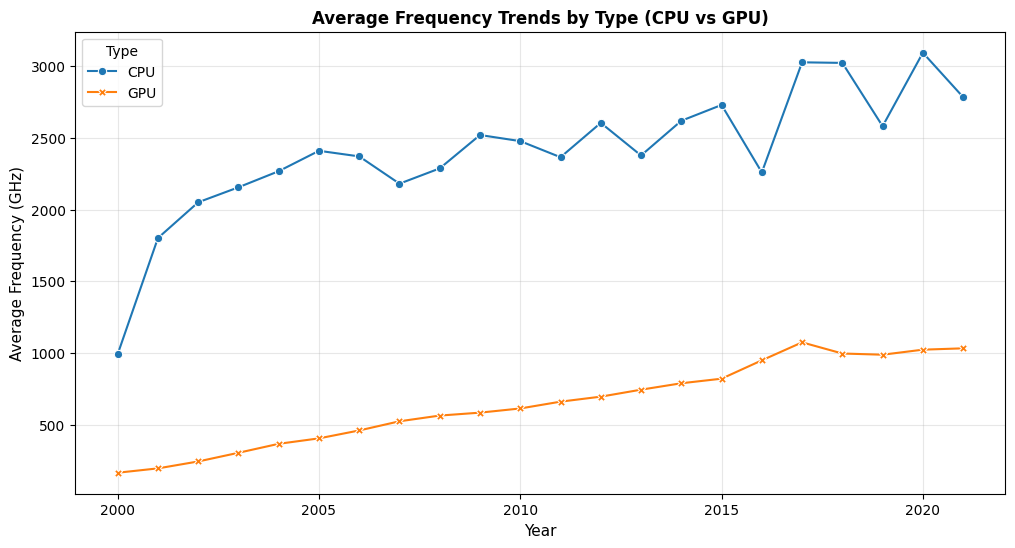

In [76]:
# Assumption 3 . CPUS have higher frequencies but GPUs are catching up trend line over the yhears
# Frequency trends by Type
print(" Frequency Trends by Type (CPU vs GPU)") 
freq_trends = df_clean.groupby(['Year', 'Type'])['Freq (MHz)'].mean().unstack()
print(freq_trends.tail(10)) 
plt.figure(figsize=(12, 6))
sns.lineplot(data=freq_trends, markers=True, dashes=False)  
plt.title('Average Frequency Trends by Type (CPU vs GPU)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Average Frequency (GHz)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(title='Type')    
plt.show()

In [78]:
# Assumption 4 .GPU Performance DOUBLES EVERY 1.5 YEARS

gpu_data = df_clean[df_clean['Type'] == 'GPU'].sort_values('Release Date')
yearly_gpu_freq = gpu_data.groupby('Year')['Freq (MHz)'].mean()

print(yearly_gpu_freq.tail(10))


Year
2012     696.046243
2013     744.693780
2014     789.401361
2015     821.253086
2016     949.266055
2017    1074.541284
2018     996.771739
2019     988.401961
2020    1023.536585
2021    1032.888889
Name: Freq (MHz), dtype: float64


In [84]:
# Assumption 5 . GPU performance improvement is a joint effect of smaller transistors, larger die size, and higher frequency.
gpu_subset = df_clean[df_clean['Type'] == 'GPU'].copy()

# Correlations for GPU performance drivers
print("\nCorrelations with GPU Frequency (Performance):")
gpu_perf_corr = gpu_subset[['Process Size (nm)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)']].corr()['Freq (MHz)'].drop('Freq (MHz)')
print(gpu_perf_corr)

print("\nInterpretation:")
print("- Smaller Process Size: Enables higher frequencies")
print("- Larger Die Size: Allows more transistors")
print("- More Transistors: Increases computational capability")
print("- Joint effect drives GPU performance improvements")

# Time series analysis for GPUs
gpu_yearly = gpu_subset.groupby('Year').agg({
    'Process Size (nm)': 'mean',
    'Die Size (mm^2)': 'mean',
    'Transistors (million)': 'mean',
    'Freq (MHz)': 'mean'
})

print("\n\nGPU Evolution Over Time:")
print(gpu_yearly.tail(8))


Correlations with GPU Frequency (Performance):
Process Size (nm)       -0.666119
Die Size (mm^2)          0.384707
Transistors (million)    0.509785
Name: Freq (MHz), dtype: float64

Interpretation:
- Smaller Process Size: Enables higher frequencies
- Larger Die Size: Allows more transistors
- More Transistors: Increases computational capability
- Joint effect drives GPU performance improvements


GPU Evolution Over Time:
      Process Size (nm)  Die Size (mm^2)  Transistors (million)   Freq (MHz)
Year                                                                        
2014          27.795918       186.367347            2175.959184   789.401361
2015          26.617284       198.839506            2455.629630   821.253086
2016          22.091743       224.449541            3972.339450   949.266055
2017          16.183486       230.339450            5201.761468  1074.541284
2018          13.826087       314.152174            7493.913043   996.771739
2019          12.852941       270.

In [86]:

#Assumption 6 . High-end GPUs tends to first use new semiconductor technologies. Low-end GPUs may use old technologies for a few years.
gpu_subset = df_clean[df_clean['Type'] == 'GPU'].copy()

# Define high-end and low-end GPUs based on transistor count quartiles
gpu_high_end = gpu_subset[gpu_subset['Transistors (million)'] >= gpu_subset['Transistors (million)'].quantile(0.75)]
gpu_low_end = gpu_subset[gpu_subset['Transistors (million)'] <= gpu_subset['Transistors (million)'].quantile(0.25)]

print(f" High-End GPUs (Top 25% by transistor count):")
print(f"  Average Process Size (nm): {gpu_high_end['Process Size (nm)'].mean():.2f}")
print(f"  Average Year: {gpu_high_end['Year'].mean():.0f}")
print(f"  Process size range: {gpu_high_end['Process Size (nm)'].min():.0f} - {gpu_high_end['Process Size (nm)'].max():.0f}")

print(f"Low-End GPUs (Bottom 25% by transistor count):")
print(f"  Average Process Size (nm): {gpu_low_end['Process Size (nm)'].mean():.2f}")
print(f"  Average Year: {gpu_low_end['Year'].mean():.0f}")
print(f"  Process size range: {gpu_low_end['Process Size (nm)'].min():.0f} - {gpu_low_end['Process Size (nm)'].max():.0f}")

process_diff = gpu_low_end['Process Size (nm)'].mean() - gpu_high_end['Process Size (nm)'].mean()
print(f"Technology Gap: Low-end uses ~{process_diff:.1f}nm LARGER process than high-end")
print("Finding: CONFIRMED - High-end GPUs adopt newer (smaller) process technologies first")

 High-End GPUs (Top 25% by transistor count):
  Average Process Size (nm): 19.96
  Average Year: 2016
  Process size range: 7 - 180
Low-End GPUs (Bottom 25% by transistor count):
  Average Process Size (nm): 122.08
  Average Year: 2005
  Process size range: 0 - 250
Technology Gap: Low-end uses ~102.1nm LARGER process than high-end
Finding: CONFIRMED - High-end GPUs adopt newer (smaller) process technologies first


In [83]:
#Assumption 7 Process Size for Intel, AMD and Nvidia lies in comparatively lower range than for ATI and other vemdors
vendor_process = df_clean.groupby('Vendor')['Process Size (nm)'].agg(['min', 'mean', 'max'])
print("Process Size statistics by Vendor (nm):")
print(vendor_process.sort_values('mean'))

foundry_process = df_clean.groupby('Foundry')['Process Size (nm)'].agg(['min', 'mean', 'max'])
print("Process Size statistics by Foundry (nm):")
print(foundry_process.sort_values('mean'))

Process Size statistics by Vendor (nm):
         min        mean    max
Vendor                         
Intel   10.0   41.788793  180.0
AMD      7.0   48.087244  180.0
NVIDIA   7.0   57.951707  250.0
ATI     40.0   94.971963  180.0
Other    0.0  145.906250  250.0
Process Size statistics by Foundry (nm):
           min        mean    max
Foundry                          
Samsung    8.0   11.600000   32.0
GF        12.0   14.837736   28.0
Renesas   40.0   40.000000   40.0
Intel     10.0   41.755396  180.0
TSMC       7.0   57.315427  250.0
Unknown   14.0   79.924942  180.0
Sony      28.0   96.300000  250.0
UMC        0.0  118.607595  180.0
NEC       90.0  135.000000  180.0
IBM      150.0  160.000000  180.0


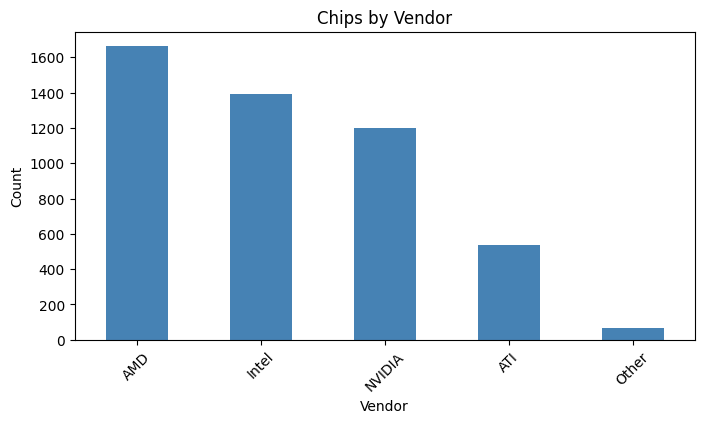

In [87]:
# Plot : Vendors
plt.figure(figsize=(8, 4))
df_clean['Vendor'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel('Vendor')
plt.ylabel('Count')
plt.title('Chips by Vendor')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# TSMC makes the highest number of chips in the world
foundry_counts = df_clean['Foundry'].value_counts()
tsmc_count = foundry_counts.get('TSMC', 0)
total_count = len(df_clean)

print(f"Chips by Foundry:")
print(foundry_counts)
print(f"TSMC share: {tsmc_count} chips ({tsmc_count/total_count*100:.1f}%)")

Chips by Foundry:
Foundry
TSMC       2178
Intel      1390
Unknown     866
GF          265
UMC          79
Samsung      60
Sony         10
IBM           3
NEC           2
Renesas       1
Name: count, dtype: int64

TSMC share: 2178 chips (44.9%)


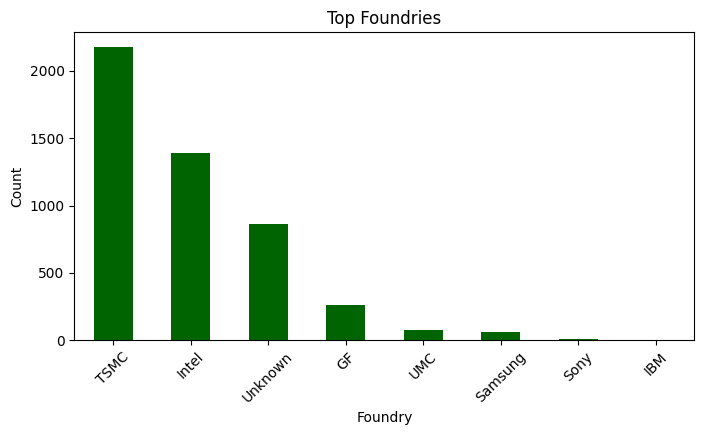

In [89]:
# Plot : Top Foundries
plt.figure(figsize=(8, 4))
df_clean['Foundry'].value_counts().head(8).plot(kind='bar', color='darkgreen')
plt.xlabel('Foundry')
plt.ylabel('Count')
plt.title('Top Foundries')
plt.xticks(rotation=45)
plt.show()


In [90]:
# Select numerical columns for correlation
numerical_features = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 
                      'Transistors (million)', 'Freq (MHz)', 'Year',
                      'Transistor_Density', 'Performance_per_Watt']

correlation_matrix = df_clean[numerical_features].corr()


print("CORRELATION ANALYSIS")


print("Full Correlation Matrix:")
print(correlation_matrix.round(3))



CORRELATION ANALYSIS
Full Correlation Matrix:
                       Process Size (nm)  TDP (W)  Die Size (mm^2)  \
Process Size (nm)                  1.000   -0.149           -0.182   
TDP (W)                           -0.149    1.000            0.599   
Die Size (mm^2)                   -0.182    0.599            1.000   
Transistors (million)             -0.346    0.450            0.631   
Freq (MHz)                        -0.281    0.097           -0.013   
Year                              -0.875    0.178            0.187   
Transistor_Density                -0.198    0.281            0.381   
Performance_per_Watt              -0.353   -0.116            0.158   

                       Transistors (million)  Freq (MHz)   Year  \
Process Size (nm)                     -0.346      -0.281 -0.875   
TDP (W)                                0.450       0.097  0.178   
Die Size (mm^2)                        0.631      -0.013  0.187   
Transistors (million)                  1.000      -0.02

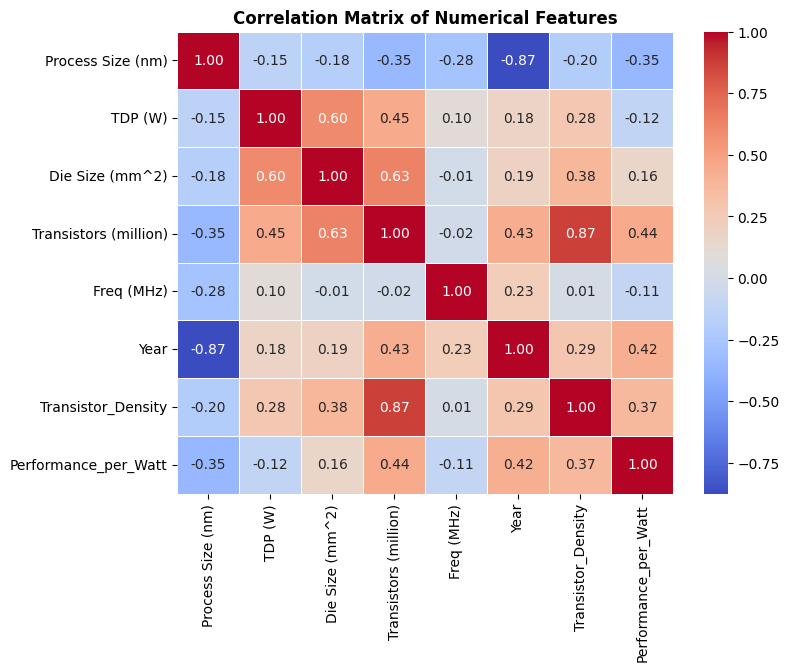

In [93]:
# PLOT CORRELATION HEATMAP
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')   
plt.show()

## Step 8: Data Encoding for Modeling

In [97]:
categorical_cols = ['Vendor', 'Foundry']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(df_model.head())

     Type Release Date  Process Size (nm)    TDP (W)  Die Size (mm^2)  \
4421  GPU   2000-01-01              150.0  38.674419            133.0   
4357  GPU   2000-03-01              250.0  98.844650             90.0   
3074  GPU   2000-03-04              250.0  79.000000            279.0   
3721  GPU   2000-04-01              180.0  23.000000            115.0   
3500  GPU   2000-04-01              180.0  23.000000            111.0   

      Transistors (million)  Freq (MHz)  Year Year_Month Year_Range  ...  \
4421                 1160.0       133.0  2000    2000-01  2000-2005  ...   
4357                   15.0       105.0  2000    2000-03  2000-2005  ...   
3074                   54.0       147.0  2000    2000-03  2000-2005  ...   
3721                   30.0       166.0  2000    2000-04  2000-2005  ...   
3500                   30.0       166.0  2000    2000-04  2000-2005  ...   

      Vendor_Other  Foundry_IBM  Foundry_Intel  Foundry_NEC  Foundry_Renesas  \
4421         False      

In [100]:
# Prepare features for modeling (excluding original categorical columns and temporal features)
# Get encoded column names from get_dummies (they're added as Vendor_0, Vendor_1, Foundry_0, etc.)

features_for_modeling = [
    'Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 
    'Transistors (million)', 'Freq (MHz)', 'Year',
    'Transistor_Density', 'Performance_per_Watt'
]

# Add one-hot encoded columns
encoded_cols = [col for col in df_model.columns if col.startswith(('Vendor_', 'Foundry_'))]
features_for_modeling.extend(encoded_cols)

print(f"Features for modeling: {features_for_modeling}")
print(f"Total features: {len(features_for_modeling)}")

X = df_model[features_for_modeling]
y = df_model['Type_GPU']  # 1 for GPU, 0 for CPU

Features for modeling: ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'Year', 'Transistor_Density', 'Performance_per_Watt', 'Foundry_encoded', 'Vendor_encoded', 'Vendor_ATI', 'Vendor_Intel', 'Vendor_NVIDIA', 'Vendor_Other', 'Foundry_IBM', 'Foundry_Intel', 'Foundry_NEC', 'Foundry_Renesas', 'Foundry_Samsung', 'Foundry_Sony', 'Foundry_TSMC', 'Foundry_UMC', 'Foundry_Unknown']
Total features: 23


In [102]:
# Standardize features - Clean NaN and infinity values first
from sklearn.preprocessing import StandardScaler

print("Checking for NaN and infinity values in X...")
print(f"NaN values: {X.isna().sum().sum()}")
print(f"Infinity values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

# Remove rows with NaN or infinity values
X_clean = X.dropna()
X_clean = X_clean[(~np.isinf(X_clean.select_dtypes(include=[np.number]))).all(axis=1)]

print(f"Rows before cleaning: {len(X)}")
print(f"Rows after cleaning: {len(X_clean)}")

# Get the indices to also clean y
valid_indices = X_clean.index
y_clean_temp = y.loc[valid_indices]

# Standardize cleaned features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

Checking for NaN and infinity values in X...
NaN values: 0
Infinity values: 4
Rows before cleaning: 4854
Rows after cleaning: 4850


In [103]:
# Create DataFrame with scaled features
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clean.columns)

# Update y to match cleaned X
y = y_clean_temp

print(f"X_scaled shape: {X_scaled_df.shape}")
print(f"y shape: {y.shape}")
print(f"Match: {X_scaled_df.shape[0] == y.shape[0]}")

X_scaled shape: (4850, 23)
y shape: (4850,)
Match: True


## Step 10: Linear Regression Model

In [109]:
# Linear Regression: Prepare, Train & Evaluate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print("LINEAR REGRESSION MODEL")

print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
print(f"Intercept: {lr_model.intercept_:.4f}")

LINEAR REGRESSION MODEL
Train R²: 0.8761 | Test R²: 0.8792
Train RMSE: 0.1752 | Test RMSE: 0.1731
Intercept: 0.5479


In [110]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

print("Linear Regression Model trained successfully!")

Linear Regression Model trained successfully!


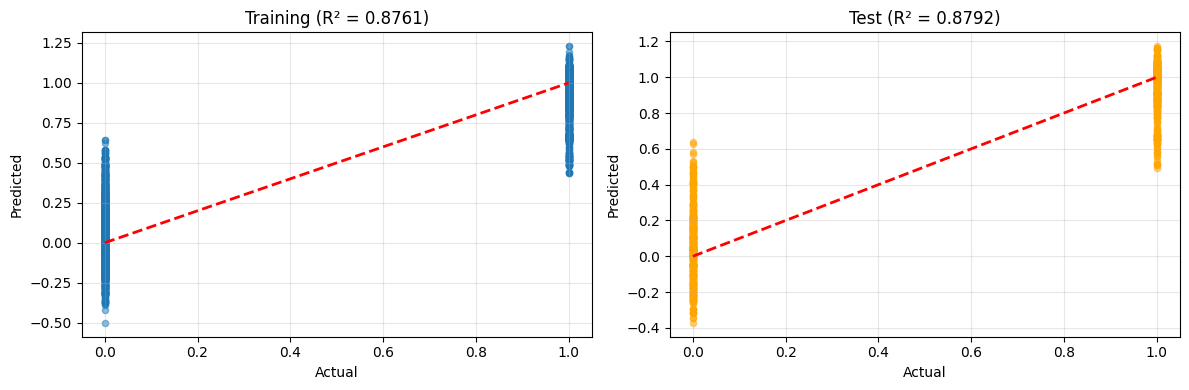

In [111]:
# Visualize Predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train predictions
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training (R² = {train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Test predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test (R² = {test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()